In [1]:
# GIVEN — Import và cài đặt chung
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
import cv2

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
np.set_printoptions(precision=4, suppress=True)

print('✓ Thư viện đã sẵn sàng.')

✓ Thư viện đã sẵn sàng.


In [2]:
def make_gaussian_kernel(sigma):
    """
    Tạo Gaussian kernel 2D chuẩn hóa.
    Kích thước kernel: (2 * ceil(3*sigma) + 1) x (2 * ceil(3*sigma) + 1)
    """
    size = int(2 * np.ceil(3 * sigma) + 1)
    center = size // 2
    x, y = np.mgrid[-center:center+1, -center:center+1]
    
    # Tính toán giá trị phân phối Gaussian 2D
    g = np.exp(-((x**2 + y**2) / (2.0 * sigma**2)))
    
    # Chuẩn hóa để tổng ma trận bằng 1
    return g / g.sum()

✓ make_gaussian_kernel: kích thước (7, 7), tổng = 1.000000


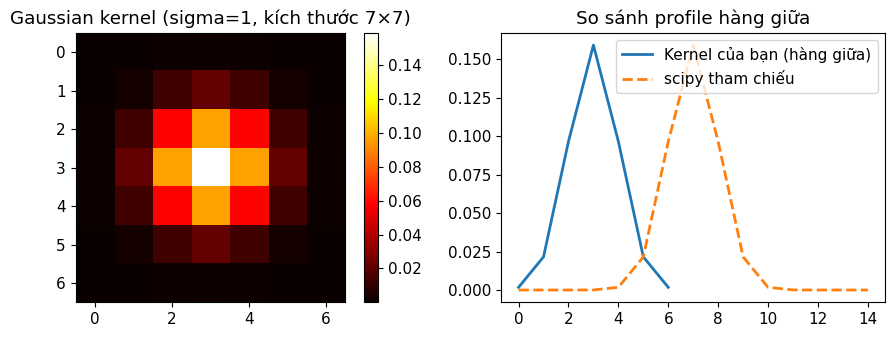

In [3]:
# TEST — Kiểm tra make_gaussian_kernel
k = make_gaussian_kernel(sigma=1.0)
assert k is not None, 'Hàm chưa trả về kết quả'
assert k.ndim == 2, f'Kernel phải là 2D, nhận được {k.ndim}D'
assert k.shape[0] == k.shape[1], 'Kernel phải vuông'
assert k.shape[0] == 7, f'Với sigma=1, kích thước phải là 7, nhận được {k.shape[0]}'
assert abs(k.sum() - 1.0) < 1e-6, f'Tổng kernel phải = 1, nhận được {k.sum():.6f}'
assert k[k.shape[0]//2, k.shape[1]//2] == k.max(), 'Giá trị lớn nhất phải ở tâm'
print(f'✓ make_gaussian_kernel: kích thước {k.shape}, tổng = {k.sum():.6f}')

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].imshow(k, cmap='hot')
axes[0].set_title(f'Gaussian kernel (sigma=1, kích thước {k.shape[0]}×{k.shape[1]})')
axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0])

# So sánh với scipy
from scipy.ndimage import gaussian_filter
delta = np.zeros((15, 15)); delta[7, 7] = 1.0
ref = gaussian_filter(delta, sigma=1.0)
axes[1].plot(k[k.shape[0]//2], label='Kernel của bạn (hàng giữa)', lw=2)
axes[1].plot(ref[7], '--', label='scipy tham chiếu', lw=2)
axes[1].set_title('So sánh profile hàng giữa')
axes[1].legend()
plt.tight_layout()
plt.show()

In [4]:
def compute_gradient(image):
    """
    Tính gradient ảnh bằng kernel Sobel 3x3.
    """
    # Kernel Sobel thủ công
    Kx = np.array([[-1,  0,  1], 
                   [-2,  0,  2], 
                   [-1,  0,  1]], dtype=float)
                   
    Ky = np.array([[ 1,  2,  1], 
                   [ 0,  0,  0], 
                   [-1, -2, -1]], dtype=float)
    
    # Dùng scipy.ndimage.convolve
    Ix = convolve(image, Kx)
    Iy = convolve(image, Ky)
    
    # Tính độ lớn (magnitude) và góc hướng (angle theo radian)
    magnitude = np.hypot(Ix, Iy)
    angle = np.arctan2(Iy, Ix)
    
    return magnitude, angle

✓ compute_gradient: magnitude max=4.000


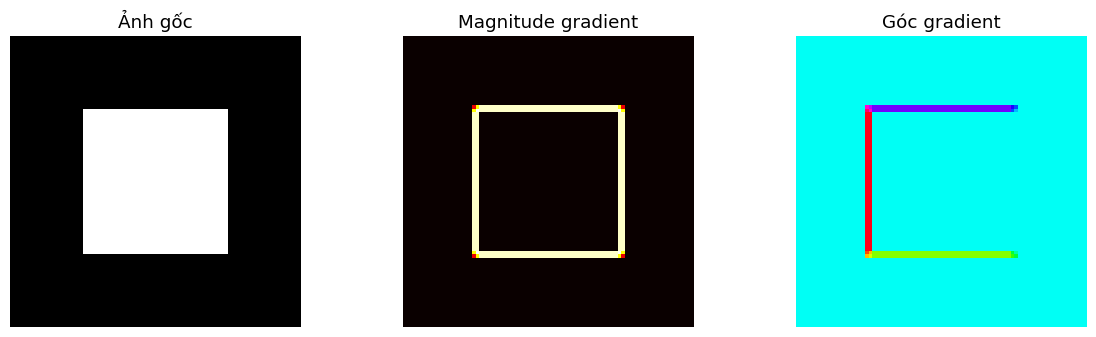

In [5]:
# TEST — Kiểm tra compute_gradient
test_img = np.zeros((20, 20), dtype=float)
test_img[:, 10:] = 1.0

result = compute_gradient(test_img)
assert result is not None, 'Hàm chưa trả về kết quả'
mag, ang = result
assert mag.shape == test_img.shape
assert ang.shape == test_img.shape
assert mag[:, 10].mean() > mag[:, 0].mean(), 'Gradient phải lớn nhất tại biên'
print(f'✓ compute_gradient: magnitude max={mag.max():.3f}')

test_rect = np.zeros((80, 80), dtype=float)
test_rect[20:60, 20:60] = 1.0
mag_rect, ang_rect = compute_gradient(test_rect)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(test_rect, cmap='gray'); axes[0].set_title('Ảnh gốc')
axes[1].imshow(mag_rect, cmap='hot'); axes[1].set_title('Magnitude gradient')
axes[2].imshow(ang_rect, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[2].set_title('Góc gradient')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

In [6]:
def non_maximum_suppression(magnitude, angle):
    """
    Làm mỏng cạnh bằng non-maximum suppression.
    """
    H, W = magnitude.shape
    suppressed = np.zeros_like(magnitude)
    
    # Chuyển radian sang độ [0, 180) để dễ lượng tử hóa
    angle_deg = angle * 180. / np.pi
    angle_deg[angle_deg < 0] += 180
    
    for i in range(1, H - 1):
        for j in range(1, W - 1):
            q = 255.0
            r = 255.0
            
            ang = angle_deg[i, j]
            
            # Hướng ngang (0 độ)
            if (0 <= ang < 22.5) or (157.5 <= ang <= 180):
                q = magnitude[i, j+1]
                r = magnitude[i, j-1]
            # Hướng chéo phải (45 độ)
            elif (22.5 <= ang < 67.5):
                q = magnitude[i+1, j-1]
                r = magnitude[i-1, j+1]
            # Hướng dọc (90 độ)
            elif (67.5 <= ang < 112.5):
                q = magnitude[i+1, j]
                r = magnitude[i-1, j]
            # Hướng chéo trái (135 độ)
            elif (112.5 <= ang < 157.5):
                q = magnitude[i-1, j-1]
                r = magnitude[i+1, j+1]

            # Giữ lại nếu là cực đại cục bộ
            if (magnitude[i, j] >= q) and (magnitude[i, j] >= r):
                suppressed[i, j] = magnitude[i, j]
            else:
                suppressed[i, j] = 0.0
                
    return suppressed

✓ NMS: pixel cạnh trước=1248, sau=184 (giảm 85.3%)


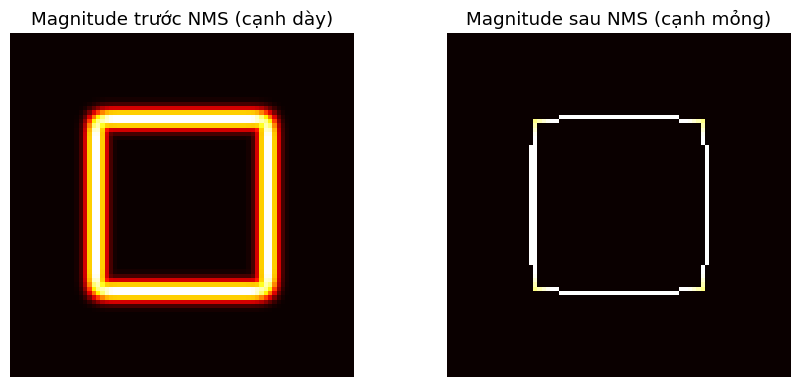

In [7]:
# TEST — Kiểm tra NMS
# Dùng kết quả gradient từ bước 2
gauss_k = make_gaussian_kernel(sigma=1.5)
smooth_rect = convolve(test_rect, gauss_k)
mag_s, ang_s = compute_gradient(smooth_rect)

nms_result = non_maximum_suppression(mag_s, ang_s)
assert nms_result is not None, 'Hàm chưa trả về kết quả'
assert nms_result.shape == mag_s.shape

# Sau NMS, số pixel khác 0 phải ít hơn trước NMS (đường cạnh mỏng hơn)
before = np.sum(mag_s > 0.1)
after  = np.sum(nms_result > 0.1)
assert after < before, f'NMS phải giảm số pixel cạnh: trước={before}, sau={after}'
print(f'✓ NMS: pixel cạnh trước={before}, sau={after} (giảm {100*(before-after)/before:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mag_s, cmap='hot')
axes[0].set_title('Magnitude trước NMS (cạnh dày)')
axes[1].imshow(nms_result, cmap='hot')
axes[1].set_title('Magnitude sau NMS (cạnh mỏng)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
def hysteresis_threshold(magnitude, t_low, t_high):
    """
    Áp dụng double thresholding và hysteresis.
    """
    strong_i, strong_j = np.where(magnitude >= t_high)
    
    # Khởi tạo ma trận logic chứa các cạnh mạnh
    edges = np.zeros_like(magnitude, dtype=bool)
    edges[strong_i, strong_j] = True
    
    # Xác định các cạnh yếu
    weak_edges = (magnitude >= t_low) & (magnitude < t_high)
    
    # Dùng tích chập với kernel 3x3 để lan truyền cạnh qua 8-liên thông
    kernel = np.ones((3, 3), dtype=bool)
    
    old_count = 0
    while True:
        # Tìm các điểm kề cạnh hiện tại (bao gồm cả strong và weak đã thành strong)
        neighbors = convolve(edges.astype(int), kernel.astype(int)) > 0
        
        # Một cạnh weak được thăng cấp nếu nó kề với một cạnh đã được xác nhận
        edges = edges | (neighbors & weak_edges)
        
        new_count = np.sum(edges)
        # Dừng lan truyền khi số pixel cạnh không còn tăng thêm
        if new_count == old_count:
            break
        old_count = new_count
        
    return edges.astype(np.uint8) * 255 # Trả về ảnh nhị phân [0, 255]

In [9]:
# TEST — Kiểm tra hysteresis thresholding
test_mag = np.array([
    [0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.9, 0.6, 0.5, 0.0],  # 0.9=strong, 0.6 và 0.5=weak (nếu t_low=0.3, t_high=0.7)
    [0.0, 0.0, 0.0, 0.0, 0.0],
])
result_ht = hysteresis_threshold(test_mag, t_low=0.3, t_high=0.7)
assert result_ht is not None, 'Hàm chưa trả về kết quả'
assert result_ht[1, 1], 'Pixel strong phải là cạnh'
assert result_ht[1, 2], 'Pixel weak kề strong phải là cạnh'
assert result_ht[1, 3], 'Pixel weak kề weak-đã-kết-nối phải là cạnh'
print('✓ hysteresis_threshold: lan truyền cạnh hoạt động đúng')

test_isolated = np.array([[0,0,0],[0,0.5,0],[0,0,0]], dtype=float)
res_iso = hysteresis_threshold(test_isolated, t_low=0.3, t_high=0.7)
assert not res_iso[1,1], 'Pixel weak cô lập KHÔNG được là cạnh'
print('✓ Pixel weak cô lập bị loại đúng')

✓ hysteresis_threshold: lan truyền cạnh hoạt động đúng
✓ Pixel weak cô lập bị loại đúng


In [10]:
def my_canny(image, sigma=1.0, t_low=0.05, t_high=0.15):
    """
    Canny edge detector hoàn chỉnh.
    """
    img = image.astype(float)
    if img.max() > 1.0:
        img = img / 255.0
        
    # Bước 1: Làm mịn Gaussian
    gauss_k = make_gaussian_kernel(sigma)
    smoothed = convolve(img, gauss_k)
    
    # Bước 2: Gradient
    mag, ang = compute_gradient(smoothed)
    
    # Bước 3: Non-Maximum Suppression
    nms_mag = non_maximum_suppression(mag, ang)
    
    # Bước 4: Hysteresis Thresholding
    edges = hysteresis_threshold(nms_mag, t_low, t_high)
    
    return edges

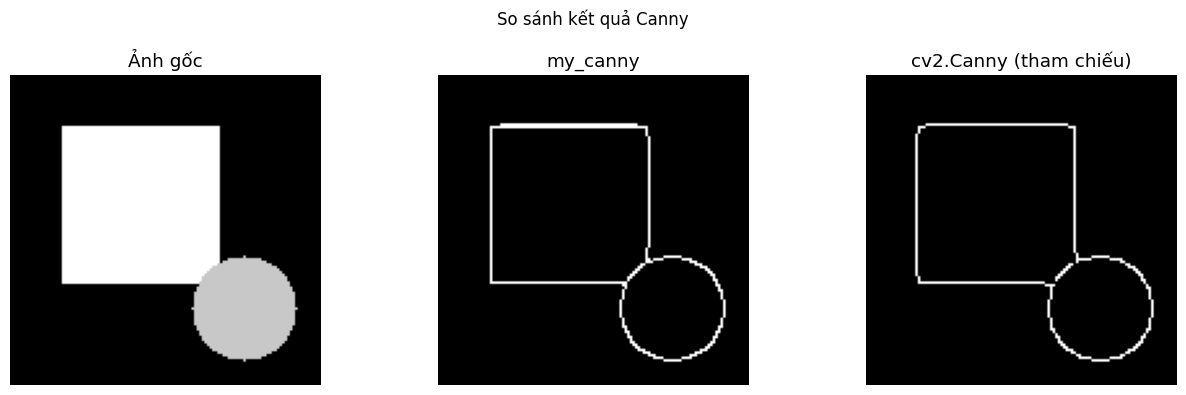

Kết quả không cần giống cv2.Canny hoàn toàn — nhưng cấu trúc cạnh phải tương đương.


In [11]:
# TEST — So sánh my_canny với cv2.Canny

# --- Ảnh test 1: hình tổng hợp ---
synth = np.zeros((120, 120), dtype=np.uint8)
cv2.rectangle(synth, (20, 20), (80, 80), 255, -1)
cv2.circle(synth, (90, 90), 20, 200, -1)

# --- Chạy my_canny ---
edges_mine = my_canny(synth, sigma=1.0, t_low=0.05, t_high=0.15)
assert edges_mine is not None, 'my_canny chưa trả về kết quả'

# --- Chạy cv2.Canny để so sánh trực quan ---
synth_blur = cv2.GaussianBlur(synth, (7, 7), 1.0)
edges_cv2 = cv2.Canny(synth_blur, threshold1=12, threshold2=36)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(synth, cmap='gray')
axes[0].set_title('Ảnh gốc')
axes[1].imshow(edges_mine, cmap='gray')
axes[1].set_title('my_canny')
axes[2].imshow(edges_cv2, cmap='gray')
axes[2].set_title('cv2.Canny (tham chiếu)')
for ax in axes: ax.axis('off')
plt.suptitle('So sánh kết quả Canny', fontsize=12)
plt.tight_layout()
plt.show()

print('Kết quả không cần giống cv2.Canny hoàn toàn — nhưng cấu trúc cạnh phải tương đương.')

<>:27: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:32: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:27: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:32: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\ngoch\AppData\Local\Temp\ipykernel_2956\1951986922.py:27: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  axes[0, i].set_title(f'my_canny ($\sigma$={sig})')
C:\Users\ngoch\AppData\Local\Temp\ipykernel_2956\1951986922.py:32: SyntaxWarning: "\s" is an invalid escape sequence.

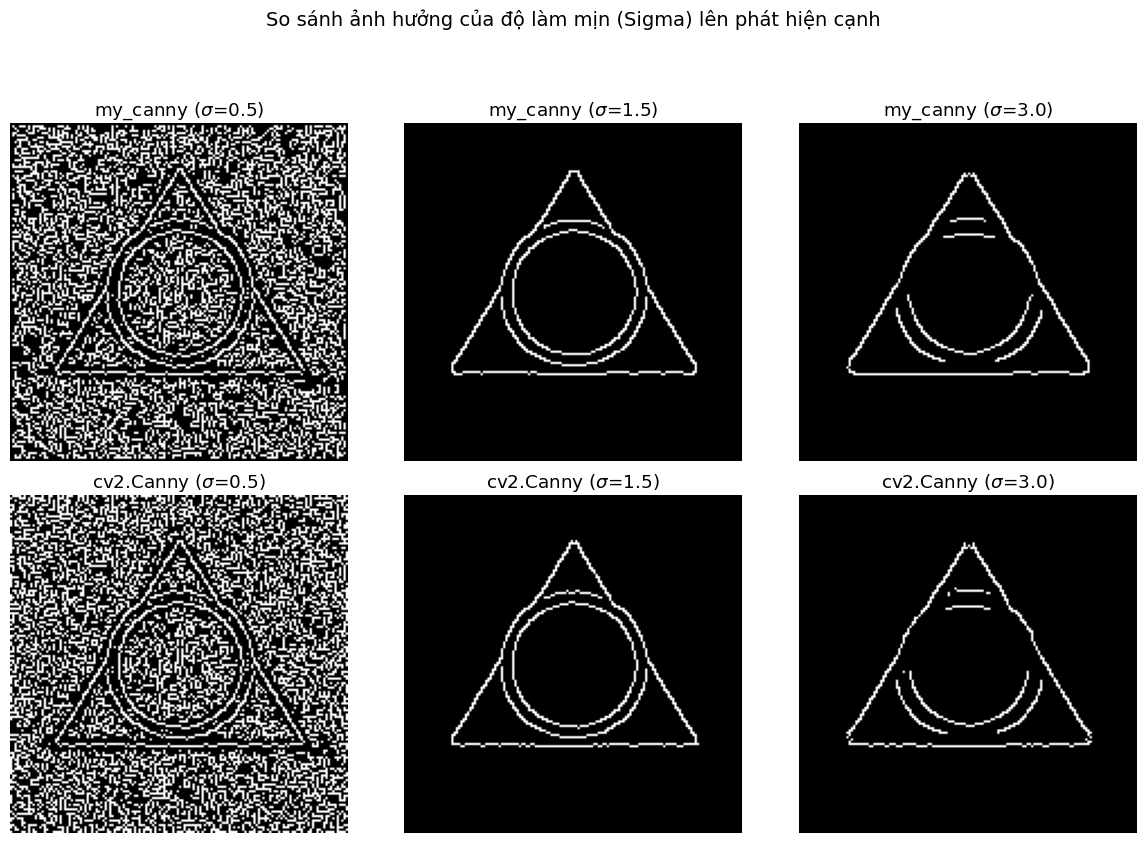

In [12]:
# TODO — Thử nghiệm với ít nhất 3 giá trị sigma trên cùng ảnh
# và so sánh trực quan kết quả my_canny với cv2.Canny

# Dữ liệu ảnh phức tạp hơn có chứa nhiễu
complex_synth = np.zeros((150, 150), dtype=np.uint8)
pts = np.array([[75,20],[130,110],[20,110]], dtype=np.int32)
cv2.fillPoly(complex_synth, [pts], 200)
cv2.circle(complex_synth, (75, 75), 30, 120, 3)
noise = np.random.randint(0, 30, complex_synth.shape, dtype=np.uint8)
complex_synth = np.clip(complex_synth.astype(int) + noise, 0, 255).astype(np.uint8)

# Danh sách các tham số Sigma để khảo sát
sigmas = [0.5, 1.5, 3.0]

fig, axes = plt.subplots(2, len(sigmas), figsize=(12, 8))

for i, sig in enumerate(sigmas):
    # Chạy hàm tự cài đặt
    edges_mine = my_canny(complex_synth, sigma=sig, t_low=0.05, t_high=0.15)
    
    # Chạy cv2.Canny (cần làm mờ trước bằng Gauss cho tương đồng)
    blur_cv = cv2.GaussianBlur(complex_synth, (0,0), sigmaX=sig)
    edges_cv2 = cv2.Canny(blur_cv, threshold1=12, threshold2=36)
    
    # Hiển thị my_canny ở hàng trên
    axes[0, i].imshow(edges_mine, cmap='gray')
    axes[0, i].set_title(f'my_canny ($\sigma$={sig})')
    axes[0, i].axis('off')
    
    # Hiển thị cv2.Canny ở hàng dưới
    axes[1, i].imshow(edges_cv2, cmap='gray')
    axes[1, i].set_title(f'cv2.Canny ($\sigma$={sig})')
    axes[1, i].axis('off')

plt.suptitle('So sánh ảnh hưởng của độ làm mịn (Sigma) lên phát hiện cạnh', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Nhận xét nhanh: Sigma càng nhỏ thì phát hiện được nhiều chi tiết nhỏ (bao gồm cả nhiễu), 
# Sigma càng lớn thì ảnh mượt hơn, chỉ giữ lại các cạnh cấu trúc chính, khử nhiễu tốt.